In [1]:
import os
import glob
from omegaconf import DictConfig
import numpy as np
from scipy import signal
from tqdm import tqdm

from src.preprocessing import clapperboard

from hydra import initialize, compose
from hydra.core.global_hydra import GlobalHydra

# SPLIT AUDIO FILE

In [2]:
# Clear any previous Hydra initialization in this kernel
GlobalHydra.instance().clear()

# Re-initialize with the correct config directory (relative to this notebook)
initialize(version_base=None, config_path="src/config")
config = compose(config_name="main")
print(config.project.name)

speech-analysis-for-you


['/home2/ducvu/project/speech-analysis-for-you/data/raw/MCI-test_afterchange.wav']
Found 1 participants to process.



Overall Batch Progress:   0%|          | 0/1 [00:00<?, ?it/s]/home2/ducvu/project/speech-analysis-for-you/src/utils/visualization.py:39: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(file_path, bbox_inches="tight")
/home2/ducvu/miniconda3/envs/dementia-speech/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


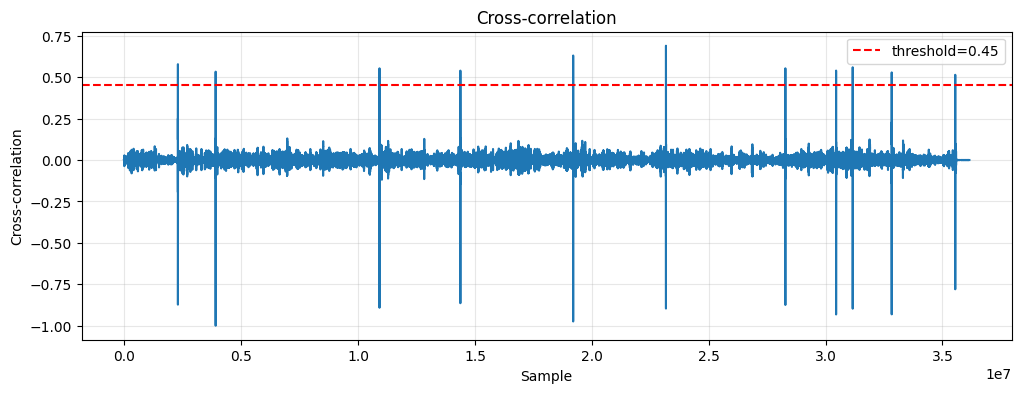

Overall Batch Progress: 100%|██████████| 1/1 [00:29<00:00, 29.01s/it]


Batch processing complete.


In [3]:
# Locate raw audio files
raw_data_folder = os.path.join(config.project.project_path, "data/raw")
audio_files = glob.glob(os.path.join(raw_data_folder, "*.wav"))

print(audio_files)

print(f"Found {len(audio_files)} participants to process.\n")

# Track successes and errors
batch_results = []

for audio_path in tqdm(audio_files, desc="Overall Batch Progress"):
    # 2. Run your pipeline
    result = clapperboard.run_split_audio_file(config, audio_path)
    batch_results.append(result)
print("\nBatch processing complete.")